## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]

train_data_processed = []
for idx in range(1, 5):
    train_data = pd.read_csv(
    rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\train_FD00{idx}.txt",sep=" ",
    header=None
)
    train_data.drop(columns=[26,27],inplace=True)

    train_data.columns = columns
    train_data.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)
    train_data['RUL'] = train_data['time_in_cycles'] / train_data.groupby('unit_number')['time_in_cycles'].transform('max') 

    train_data.drop(columns=['unit_number', 'setting_1', 'setting_2'],inplace=True)

    train_data_processed.append(train_data)
    print(f"Processed train_FD00{idx}.txt, number of rows: {train_data.shape[0]}")
train_data_processed = pd.concat(train_data_processed, ignore_index=True)

Processed train_FD001.txt, number of rows: 20631
Processed train_FD002.txt, number of rows: 53759
Processed train_FD003.txt, number of rows: 24720
Processed train_FD004.txt, number of rows: 61249


In [3]:
pd.DataFrame(train_data_processed)


,time_in_cycles,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.005208
1,2,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.010417
2,3,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.015625
3,4,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.020833
4,5,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.026042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160354,251,605.33,1516.36,1315.28,15.46,404.59,2319.66,8840.16,46.08,380.16,2388.73,8185.69,8.4541,372,29.11,17.5234,0.984314
160355,252,643.42,1598.92,1426.77,21.57,567.59,2388.47,9117.12,48.04,535.02,2388.46,8185.47,8.2221,396,39.38,23.7151,0.988235
160356,253,643.68,1607.72,1430.56,21.57,569.04,2388.51,9126.53,48.24,535.41,2388.48,8193.94,8.2525,395,39.78,23.8270,0.992157
160357,254,555.77,1381.29,1148.18,7.96,199.93,2223.78,8403.64,42.53,187.92,2388.83,8125.64,9.0515,337,15.26,9.0774,0.996078


## Splitting Dataset

In [4]:
from sklearn.model_selection import train_test_split
X = train_data_processed.drop(columns=['RUL'])
y = train_data_processed['RUL']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training XGBoost Model

In [5]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
import pickle
with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [7]:
# Save the trained XGBoost model
# Load the saved XGBoost model
with open("xgboost_model.pkl", "rb") as f:
    Regressor = pickle.load(f)


### Prediction MSE & RMSE

In [8]:
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

Mean Squared Error: 0.004179733323434839
Root Mean Squared Error (RMSE): 0.06465085709744953


In [9]:
test_data_processed = []

for idx in range(1, 5):
    test_data_rul = pd.read_csv(rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\RUL_FD00{idx}.txt",sep=" ", header=None)
    test_data = pd.read_csv(rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\test_FD00{idx}.txt",sep=" ", header=None)

    test_data.drop(columns=[26, 27], inplace=True)

    columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]
    test_data.columns = columns
    test_data.drop(columns=['Nf_dmd', 'PCNfR_dmd', 'P2', 'T2', 'TRA', 'farB', 'epr'], inplace=True)

    eol = []

    for un in test_data['unit_number'].unique():
        temp_data = test_data[test_data['unit_number'] == un]
        eol_temp = test_data_rul.iloc[un - 1].values[0]  
        eol_temp_list = [eol_temp] * len(temp_data)
        eol.extend(eol_temp_list)
    test_data['RUL'] = test_data['time_in_cycles'].values / (test_data.groupby('unit_number')['time_in_cycles'].transform('max').values + eol)
    test_data.drop(columns=['unit_number', 'setting_1', 'setting_2'], inplace=True)
    test_data_processed.append(test_data)
    print(f" Processed test_FD00{idx}.txt → Rows: {test_data.shape[0]}")

test_data_processed = pd.concat(test_data_processed, ignore_index=True)
pd.DataFrame(test_data_processed)

 Processed test_FD001.txt → Rows: 13096
 Processed test_FD002.txt → Rows: 33991
 Processed test_FD003.txt → Rows: 16596
 Processed test_FD004.txt → Rows: 41214


,time_in_cycles,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735,0.006993
1,2,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916,0.013986
2,3,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166,0.020979
3,4,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737,0.027972
4,5,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130,0.034965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104892,277,550.30,1364.40,1129.17,5.72,138.34,2212.35,8351.73,42.30,130.87,2388.50,8112.61,9.4427,331,10.53,6.2620,0.902280
104893,278,608.00,1494.75,1260.88,13.66,334.75,2324.23,8758.69,44.53,314.51,2388.33,8086.83,9.2772,366,24.33,14.6486,0.905537
104894,279,555.92,1370.65,1130.97,8.00,194.92,2223.57,8370.49,42.33,182.76,2388.64,8100.84,9.3982,336,14.69,8.8389,0.908795
104895,280,608.19,1489.11,1256.25,13.66,333.15,2324.19,8753.04,44.78,314.17,2388.37,8085.24,9.2727,366,24.44,14.6887,0.912052


In [10]:

from sklearn.metrics import mean_squared_error

# Predictions
y_pred = model.predict(X_test)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Squared Error: {mse:.6f}')
print(f'Root Mean Squared Error: {rmse:.6f}')

# Create DataFrame for analysis
df_preds = pd.DataFrame({
    "True_RUL": y_test.values,
    "Predicted_RUL": y_pred
})

# Calculate absolute error and percentage error
df_preds['Absolute_Error'] = np.abs(df_preds['Predicted_RUL'] - df_preds['True_RUL'])
df_preds['Percentage_Error'] = (df_preds['Absolute_Error'] / df_preds['True_RUL']) * 100

# Show first 5 rows for quick check
print("\nFirst 5 predictions with errors:")
print(df_preds.head())

# Optional: Calculate a simple "precision accuracy"
mean_percentage_error = df_preds['Percentage_Error'].mean()
precision_accuracy = 100 - mean_percentage_error
print(f"\nApproximate Prediction Accuracy: {precision_accuracy:.2f}%")


Mean Squared Error: 0.004180
Root Mean Squared Error: 0.064651

First 5 predictions with errors:
   True_RUL  Predicted_RUL  Absolute_Error  Percentage_Error
0  0.958084       0.984569        0.026486          2.764441
1  0.942857       0.955169        0.012312          1.305843
2  0.271523       0.181266        0.090258         33.241214
3  0.005291      -0.002033        0.007324        138.432767
4  0.187773       0.205551        0.017778          9.467707

Approximate Prediction Accuracy: 85.27%


In [11]:
fd_001_test_rul = pd.read_csv(r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\RUL_FD002.txt",sep=" ", header=None)
fd_001_test = pd.read_csv(r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\test_FD002.txt",sep=" ", header=None)
fd_001_test.drop(columns=[26, 27], inplace=True)
fd_001_test.columns = columns
fd_001_test.drop(columns=['Nf_dmd', 'PCNfR_dmd', 'P2', 'T2', 'TRA', 'farB', 'epr'], inplace=True)

eol = [] 
for un in fd_001_test['unit_number'].unique():
    temp_data = fd_001_test[fd_001_test['unit_number'] == un]
    eol_temp = fd_001_test_rul.iloc[un - 1].values[0]  
    eol_temp_list = [eol_temp for _ in range(len(temp_data))]
    eol.extend(eol_temp_list)
fd_001_test['RUL'] = fd_001_test['time_in_cycles'].values / (
    fd_001_test.groupby('unit_number')['time_in_cycles'].transform('max').values + eol
)


In [12]:
print(f"Total number of unique engines: {len(fd_001_test['unit_number'].unique())}")
print(f"Total data rows: {len(fd_001_test)}")
#  Print all unique engine IDs and their total count
unique_engines = fd_001_test['unit_number'].unique()
print(f"List of engine IDs:\n{unique_engines}")


Total number of unique engines: 259
Total data rows: 33991
List of engine IDs:
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 

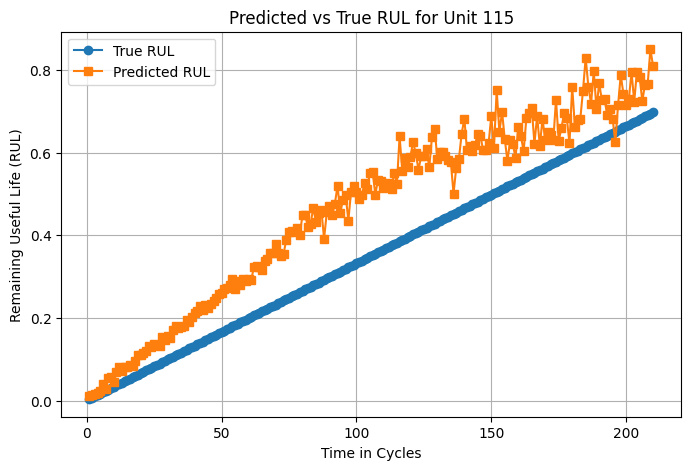

In [ ]:
from IPython.display import clear_output
import time
import os
output_dir = r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\RUL_Plots"
os.makedirs(output_dir, exist_ok=True)
unit_ids = fd_001_test['unit_number'].unique()
for unit_id in fd_001_test['unit_number'].unique():
    unit_data = fd_001_test[fd_001_test['unit_number'] == unit_id]
    true_rul = unit_data['RUL']
    features = ['time_in_cycles', 'T24', 'T30', 'T50', 'P15', 'P30', 
                'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 
                'htBleed', 'W31', 'W32']
    X_test_unit = unit_data[features]
    pred_rul = Regressor.predict(X_test_unit)
    plt.figure(figsize=(8, 5))
    plt.plot(unit_data['time_in_cycles'], true_rul, label='True RUL', marker='o')
    plt.plot(unit_data['time_in_cycles'], pred_rul, label='Predicted RUL', marker='s')
    plt.xlabel('Time in Cycles')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.title(f'Predicted vs True RUL for Unit {unit_id}')
    plt.legend()
    plt.grid(True)
    plot_path = os.path.join(output_dir, f"Unit_{unit_id}_RUL.png")
    plt.savefig(plot_path)
    clear_output(wait=True)
    plt.show()
    time.sleep(1)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2',
           'T24','T30','T50','P2','P15','P30','Nf','Nc','epr','Ps30','phi',
           'NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]

train_data_processed = []
for idx in range(1, 5):
    train_data = pd.read_csv(
rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\train_FD00{idx}.txt",
    sep=" ",header=None)
    train_data.drop(columns=[26,27],inplace=True)

    train_data.columns = columns
    train_data.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],
    inplace=True)
    train_data['RUL'] = train_data['time_in_cycles'] / train_data.groupby('unit_number')
    ['time_in_cycles'].transform('max') 

    train_data.drop(columns=['unit_number', 'setting_1', 'setting_2'],inplace=True)

    train_data_processed.append(train_data)
    print(f"Processed train_FD00{idx}.txt, number of rows: {train_data.shape[0]}")
train_data_processed = pd.concat(train_data_processed, ignore_index=True)


pd.DataFrame(train_data_processed)


from sklearn.model_selection import train_test_split
X = train_data_processed.drop(columns=['RUL'])
y = train_data_processed['RUL']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                     test_size=0.2, random_state=42)

from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(X_train, y_train)


import pickle
with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)


# Save the trained XGBoost model
# Load the saved XGBoost model
with open("xgboost_model.pkl", "rb") as f:
    Regressor = pickle.load(f)



from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')


test_data_processed = []

for idx in range(1, 5):
    test_data_rul = pd.read_csv(
rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\RUL_FD00{idx}.txt",
    sep=" ", header=None)
    test_data = pd.read_csv(
rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\test_FD00{idx}.txt",
    sep=" ", header=None)

    test_data.drop(columns=[26, 27], inplace=True)

    columns = ['unit_number','time_in_cycles','setting_1','setting_2',
               'TRA','T2','T24','T30','T50','P2','P15','P30','Nf', 'Nc',
               'epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd',
               'PCNfR_dmd','W31','W32' ]
    test_data.columns = columns
    test_data.drop(columns=[
        'Nf_dmd', 'PCNfR_dmd', 'P2', 'T2', 'TRA', 'farB', 'epr'], 
    inplace=True)

    eol = []

    for un in test_data['unit_number'].unique():
        temp_data = test_data[test_data['unit_number'] == un]
        eol_temp = test_data_rul.iloc[un - 1].values[0]  
        eol_temp_list = [eol_temp] * len(temp_data)
        eol.extend(eol_temp_list)
    test_data['RUL'] = test_data[
        'time_in_cycles'].values / (test_data.groupby('unit_number')
    ['time_in_cycles'].transform('max').values + eol)
    test_data.drop(columns=['unit_number', 'setting_1', 'setting_2'], inplace=True)
    test_data_processed.append(test_data)
    print(f" Processed test_FD00{idx}.txt → Rows: {test_data.shape[0]}")

test_data_processed = pd.concat(test_data_processed, ignore_index=True)
pd.DataFrame(test_data_processed)



from sklearn.metrics import mean_squared_error

# Predictions
y_pred = model.predict(X_test)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Squared Error: {mse:.6f}')
print(f'Root Mean Squared Error: {rmse:.6f}')

# Create DataFrame for analysis
df_preds = pd.DataFrame({
    "True_RUL": y_test.values,
    "Predicted_RUL": y_pred
})

# Calculate absolute error and percentage error
df_preds['Absolute_Error'] = np.abs(df_preds[
    'Predicted_RUL'] - df_preds['True_RUL'])
df_preds['Percentage_Error'] = (df_preds[
    'Absolute_Error'] / df_preds['True_RUL']) * 100

# Show first 5 rows for quick check
print("\nFirst 5 predictions with errors:")
print(df_preds.head())

# Optional: Calculate a simple "precision accuracy"
mean_percentage_error = df_preds['Percentage_Error'].mean()
precision_accuracy = 100 - mean_percentage_error
print(f"\nApproximate Prediction Accuracy: {precision_accuracy:.2f}%")


fd_001_test_rul = pd.read_csv(
r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\RUL_FD002.txt",
sep=" ", header=None)
fd_001_test = pd.read_csv(
r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\test_FD002.txt",
sep=" ", header=None)
fd_001_test.drop(columns=[26, 27], inplace=True)
fd_001_test.columns = columns
fd_001_test.drop(columns=['Nf_dmd', 'PCNfR_dmd', 'P2', 'T2',
                           'TRA', 'farB', 'epr'], inplace=True)

eol = [] 
for un in fd_001_test['unit_number'].unique():
    temp_data = fd_001_test[fd_001_test['unit_number'] == un]
    eol_temp = fd_001_test_rul.iloc[un - 1].values[0]  
    eol_temp_list = [eol_temp for _ in range(len(temp_data))]
    eol.extend(eol_temp_list)
fd_001_test['RUL'] = fd_001_test['time_in_cycles'].values / (
    fd_001_test.groupby('unit_number')[
        'time_in_cycles'].transform('max').values + eol)



print(f"Total number of unique engines: {len(fd_001_test[
    'unit_number'].unique())}")
print(f"Total data rows: {len(fd_001_test)}")
#  Print all unique engine IDs and their total count
unique_engines = fd_001_test['unit_number'].unique()
print(f"List of engine IDs:\n{unique_engines}")


from IPython.display import clear_output
import time
import os
output_dir = (
    r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\RUL_Plots")
os.makedirs(output_dir, exist_ok=True)
unit_ids = fd_001_test['unit_number'].unique()
for unit_id in fd_001_test['unit_number'].unique():
    unit_data = fd_001_test[fd_001_test['unit_number'] == unit_id]
    true_rul = unit_data['RUL']
    features = ['time_in_cycles', 'T24', 'T30', 'T50', 'P15', 'P30', 
                'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 
                'htBleed', 'W31', 'W32']
    X_test_unit = unit_data[features]
    pred_rul = Regressor.predict(X_test_unit)
    plt.figure(figsize=(8, 5))
    plt.plot(unit_data['time_in_cycles'], true_rul, label='True RUL', marker='o')
    plt.plot(unit_data['time_in_cycles'], pred_rul, label='Predicted RUL', marker='s')
    plt.xlabel('Time in Cycles')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.title(f'Predicted vs True RUL for Unit {unit_id}')
    plt.legend()
    plt.grid(True)
    plot_path = os.path.join(output_dir, f"Unit_{unit_id}_RUL.png")
    plt.savefig(plot_path)
    clear_output(wait=True)
    plt.show()
    time.sleep(1)





ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (100, 2) + inhomogeneous part.